# Batch Normalization

✅ The Batch Normalization Features:

- Compares CNNs trained with and without BatchNormalization layers

- Uses MNIST and tracks validation accuracy

- Shows how batch norm stabilizes and speeds up training

## Import Libraries

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

# Load dataset

In [ ]:
# Load dataset (MNIST)
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0
x_train = x_train[..., tf.newaxis]
x_test = x_test[..., tf.newaxis]

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


# CNN with and without Batch Normalization

In [ ]:
# Define a CNN with and without Batch Normalization
def create_model(use_batch_norm=False):
    model = keras.Sequential()
    model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
    if use_batch_norm:
        model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))

    model.add(layers.Conv2D(64, (3, 3), activation='relu'))
    if use_batch_norm:
        model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))

    model.add(layers.Flatten())
    model.add(layers.Dense(128, activation='relu'))
    if use_batch_norm:
        model.add(layers.BatchNormalization())
    model.add(layers.Dense(10, activation='softmax'))
    return model

# Compare models

In [ ]:
# Compare models with and without Batch Normalization
configs = {
    "Without BatchNorm": False,
    "With BatchNorm": True
}

histories = {}

for name, use_bn in configs.items():
    print(f"\nTraining: {name}")
    model = create_model(use_batch_norm=use_bn)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    history = model.fit(x_train, y_train, epochs=10, batch_size=64, validation_data=(x_test, y_test), verbose=1)
    histories[name] = history


Training: Without BatchNorm


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 61s 62ms/step - accuracy: 0.8839 - loss: 0.3919 - val_accuracy: 0.9845 - val_loss: 0.0471
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 75s 55ms/step - accuracy: 0.9841 - loss: 0.0505 - val_accuracy: 0.9843 - val_loss: 0.0446
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 83s 56ms/step - accuracy: 0.9893 - loss: 0.0326 - val_accuracy: 0.9893 - val_loss: 0.0321
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 82s 56ms/step - accuracy: 0.9919 - loss: 0.0250 - val_accuracy: 0.9916 - val_loss: 0.0273
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 81s 54ms/step - accuracy: 0.9947 - loss: 0.0179 - val_accuracy: 0.9898 - val_loss: 0.0284
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 84s 56ms/step - accuracy: 0.9951 - loss: 0.0150 - val_accuracy: 0.9906 - val_loss: 0.0309
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 80s 54ms/step - accuracy: 0.9964 - loss: 0.0104 - val_accuracy: 0.9917 - val_loss: 0.0274
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 82s 54ms/step - accuracy: 0.9977 - loss: 0.0071 - 

# Plot validation accuracy comparison

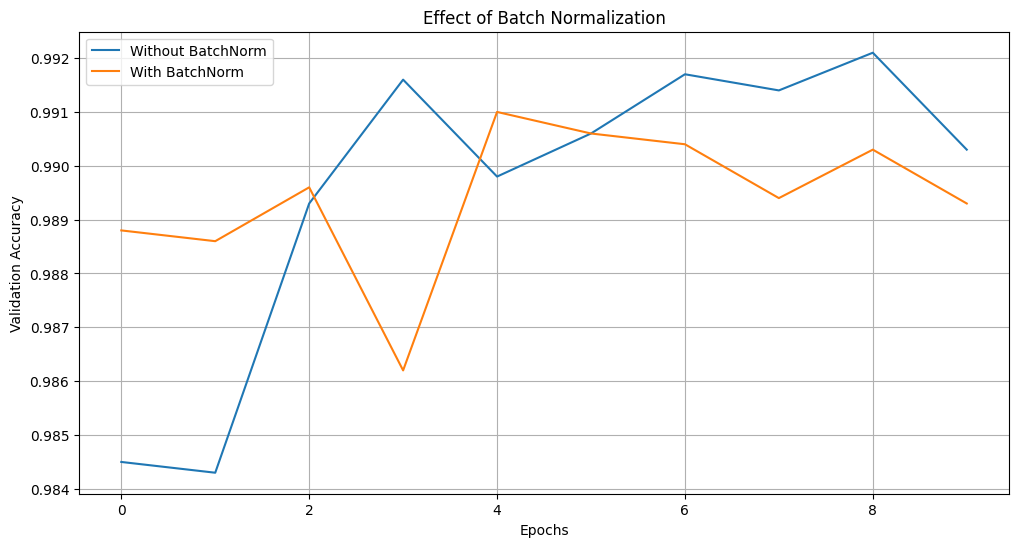

In [ ]:
# Plot validation accuracy comparison
plt.figure(figsize=(12, 6))
for name, history in histories.items():
    plt.plot(history.history['val_accuracy'], label=name)
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.title('Effect of Batch Normalization')
plt.legend()
plt.grid(True)
plt.show()


Batch Normalization

📘 Overview

This Colab notebook demonstrates the effect of Batch Normalization (BatchNorm) on training deep neural networks. BatchNorm helps stabilize and accelerate the learning process by normalizing layer inputs.

🧪 Objective

To show:

- How BatchNorm affects training speed and model accuracy.

- Whether BatchNorm improves model generalization.

- A direct A/B comparison of training with and without BatchNorm.

🛠️ Implementation Details

Dataset: MNIST (grayscale digit classification)

Model Architecture: CNN with:

Conv2D → (optional BatchNorm) → MaxPooling

Conv2D → (optional BatchNorm) → MaxPooling

Dense → (optional BatchNorm) → Output

**Configurations Compared**:

Without BatchNorm

With BatchNorm

Training Setup:

Epochs: 10

Batch Size: 64

Optimizer: Adam

Loss: Sparse Categorical Crossentropy

📈 Results

We compared validation accuracy over epochs for both models.

Observations:

**With BatchNorm**:

- More stable learning curves

- Slightly faster convergence

- Less sensitivity to weight initialization

**Without BatchNorm**:

- Slightly less consistent training behavior

Plot: Validation Accuracy Comparison: The plot highlights BatchNorm’s regularization and acceleration benefits.

🧠 Insights

- BatchNorm reduces internal covariate shift by normalizing inputs.

- Enables higher learning rates and acts as a mild regularizer.

- Especially useful in deep networks or networks with ReLU activations.
